In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [2]:
df = pd.read_csv('car-details.csv')
df.sample(5)

,name,company,model,edition,year,owner,fuel,seller_type,transmission,km_driven,mileage_mpg,engine_cc,max_power_bhp,torque_nm,seats,selling_price
5105,Hyundai Accent GLS 1.6 ABS,Hyundai,Accent,GLS 1.6 ABS,2004,Second,Petrol,Individual,Manual,110000,33.84,1599.0,94.0,122.583125,5.0,110000
5692,Maruti Swift VDI,Maruti,Swift,VDI,2012,First,Diesel,Individual,Manual,90000,53.80,1248.0,74.0,190.000000,5.0,325000
998,Honda BRV i-VTEC V CVT,Honda,BRV,i-VTEC V CVT,2017,First,Petrol,Individual,Automatic,15000,36.20,1497.0,117.3,145.000000,7.0,950000
417,Maruti Swift VDI Optional,Maruti,Swift,VDI Optional,2016,First,Diesel,Individual,Manual,47000,59.22,1248.0,74.0,190.000000,5.0,600000
1183,Maruti Swift ZDi,Maruti,Swift,ZDi,2014,Second,Diesel,Individual,Manual,100000,53.80,1248.0,74.0,190.000000,5.0,509999


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6926 entries, 0 to 6925
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   str    
 1   company        6926 non-null   str    
 2   model          6926 non-null   str    
 3   edition        6926 non-null   str    
 4   year           6926 non-null   int64  
 5   owner          6926 non-null   str    
 6   fuel           6926 non-null   str    
 7   seller_type    6926 non-null   str    
 8   transmission   6926 non-null   str    
 9   km_driven      6926 non-null   int64  
 10  mileage_mpg    6718 non-null   float64
 11  engine_cc      6718 non-null   float64
 12  max_power_bhp  6717 non-null   float64
 13  torque_nm      6717 non-null   float64
 14  seats          6718 non-null   float64
 15  selling_price  6926 non-null   int64  
dtypes: float64(5), int64(3), str(8)
memory usage: 865.9 KB


In [4]:
df.isna().sum()

name               0
company            0
model              0
edition            0
year               0
owner              0
fuel               0
seller_type        0
transmission       0
km_driven          0
mileage_mpg      208
engine_cc        208
max_power_bhp    209
torque_nm        209
seats            208
selling_price      0
dtype: int64

In [5]:
df.shape

(6926, 16)

In [6]:
for col in df.select_dtypes(include='O').columns:
    print(f'Column: {col}')
    print(f'Cardinality: {df[col].nunique()}')
    print(df[col].unique())
    print(df[col].value_counts(normalize=True))
    print()

Column: name
Cardinality: 2058
<StringArray>
[                      'Maruti Swift Dzire VDI',
                 'Skoda Rapid 1.5 TDI Ambition',
                     'Honda City 2017-2020 EXi',
                    'Hyundai i20 Sportz Diesel',
                       'Maruti Swift VXI BSIII',
                'Hyundai Xcent 1.2 VTVT E Plus',
                 'Maruti Wagon R LXI DUO BSIII',
                           'Maruti 800 DX BSII',
                             'Toyota Etios VXD',
         'Ford Figo Diesel Celebration Edition',
 ...
                    'Toyota Innova 2.5 E 7 STR',
                            'Honda City ZXi AT',
                 'Ford Fiesta 1.4 Duratorq EXI',
                           'Chevrolet Cruze LT',
                  'Maruti Celerio ZXI AMT BSIV',
                        'Tata Bolt Revotron XM',
           'Tata Manza Aura (ABS) Safire BS IV',
                   'Tata Nexon 1.5 Revotorq XT',
     'Ford Freestyle Titanium Plus Diesel BSIV',
 'Toyota Innova 2.5

C:\Users\sj941\AppData\Local\Temp\ipykernel_5528\2631539205.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='O').columns:


In [7]:
df = df.drop(columns=['name', 'model', 'edition'])
df.head()

,company,year,owner,fuel,seller_type,transmission,km_driven,mileage_mpg,engine_cc,max_power_bhp,torque_nm,seats,selling_price
0,Maruti,2014,First,Diesel,Individual,Manual,145500,55.00,1248.0,74.00,190.000000,5.0,450000
1,Skoda,2014,Second,Diesel,Individual,Manual,120000,49.70,1498.0,103.52,250.000000,5.0,370000
2,Honda,2006,Third,Petrol,Individual,Manual,140000,41.60,1497.0,78.00,124.544455,5.0,158000
3,Hyundai,2010,First,Diesel,Individual,Manual,127000,54.06,1396.0,90.00,219.668960,5.0,225000
4,Maruti,2007,First,Petrol,Individual,Manual,120000,37.84,1298.0,88.20,112.776475,5.0,130000


In [8]:
df = df.drop_duplicates()
df.head()

,company,year,owner,fuel,seller_type,transmission,km_driven,mileage_mpg,engine_cc,max_power_bhp,torque_nm,seats,selling_price
0,Maruti,2014,First,Diesel,Individual,Manual,145500,55.00,1248.0,74.00,190.000000,5.0,450000
1,Skoda,2014,Second,Diesel,Individual,Manual,120000,49.70,1498.0,103.52,250.000000,5.0,370000
2,Honda,2006,Third,Petrol,Individual,Manual,140000,41.60,1497.0,78.00,124.544455,5.0,158000
3,Hyundai,2010,First,Diesel,Individual,Manual,127000,54.06,1396.0,90.00,219.668960,5.0,225000
4,Maruti,2007,First,Petrol,Individual,Manual,120000,37.84,1298.0,88.20,112.776475,5.0,130000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
X = df.drop(columns='selling_price')
y = df.selling_price.copy()

print(X.shape, y.shape)

(6907, 12) (6907,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5525, 12) (5525,)
(1382, 12) (1382,)


In [12]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = [col for col in X_train.columns if col not in num_cols]

print(num_cols)
print(cat_cols)

['year', 'km_driven', 'mileage_mpg', 'engine_cc', 'max_power_bhp', 'torque_nm', 'seats']
['company', 'owner', 'fuel', 'seller_type', 'transmission']


In [13]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

regressor = RandomForestRegressor(
    n_estimators=10, max_depth=5, random_state=42
)

rf_model = Pipeline(steps=[
    ('pre', preprocessor),
    ('reg', regressor)
])
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['company','year','owner',...,'max_power_bhp','torque_nm','seats']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated 

In [14]:
y_train_pred = rf_model.predict(X_train)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
print(f'Train RMSE: {train_rmse:,.3f}')

y_test_pred = rf_model.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print(f'Test RMSE: {test_rmse:,.3f}')

Train RMSE: 169,947.490
Test RMSE: 172,392.131


In [16]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error

param_grid = {
      'reg__n_estimators': [200, 300, 500],
      'reg__max_depth': [8, 10, 15, 20],
      'reg__min_samples_split': [5, 10, 15],
      'reg__min_samples_leaf': [2, 4, 6]
  }

search = RandomizedSearchCV(
      rf_model, param_grid, n_iter=20, cv=5,
      scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42
  )
search.fit(X_train, y_train)

print(search.best_params_)

y_train_pred = search.predict(X_train)
y_test_pred = search.predict(X_test)
print(f'Train RMSE: {root_mean_squared_error(y_train, y_train_pred):,.3f}')
print(f'Test RMSE: {root_mean_squared_error(y_test, y_test_pred):,.3f}')

{'reg__n_estimators': 500, 'reg__min_samples_split': 5, 'reg__min_samples_leaf': 2, 'reg__max_depth': 15}
Train RMSE: 98,364.928
Test RMSE: 127,238.032


In [17]:
from xgboost import XGBRegressor
  
xgb_model = Pipeline(steps=[
      ('pre', preprocessor),
      ('reg', XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1))
  ])
xgb_model.fit(X_train, y_train)

y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)
print(f'Train RMSE: {root_mean_squared_error(y_train, y_train_pred):,.3f}')
print(f'Test RMSE: {root_mean_squared_error(y_test, y_test_pred):,.3f}')


Train RMSE: 34,682.637
Test RMSE: 131,266.156


In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
        'reg__n_estimators': [200, 300, 500],
        'reg__max_depth': [3, 4, 5],
        'reg__learning_rate': [0.01, 0.05, 0.1],
        'reg__subsample': [0.6, 0.8, 1.0],
        'reg__colsample_bytree': [0.6, 0.8, 1.0],
        'reg__min_child_weight': [3, 5, 10]
    }

xgb_search = RandomizedSearchCV(
        xgb_model, param_grid, n_iter=20, cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42
    )
xgb_search.fit(X_train, y_train)

print(xgb_search.best_params_)

y_train_pred = xgb_search.predict(X_train)
y_test_pred = xgb_search.predict(X_test)
print(f'Train RMSE: {root_mean_squared_error(y_train, y_train_pred):,.3f}')
print(f'Test RMSE: {root_mean_squared_error(y_test, y_test_pred):,.3f}')

{'reg__subsample': 0.6, 'reg__n_estimators': 500, 'reg__min_child_weight': 5, 'reg__max_depth': 4, 'reg__learning_rate': 0.1, 'reg__colsample_bytree': 0.6}
Train RMSE: 84,587.391
Test RMSE: 139,725.297


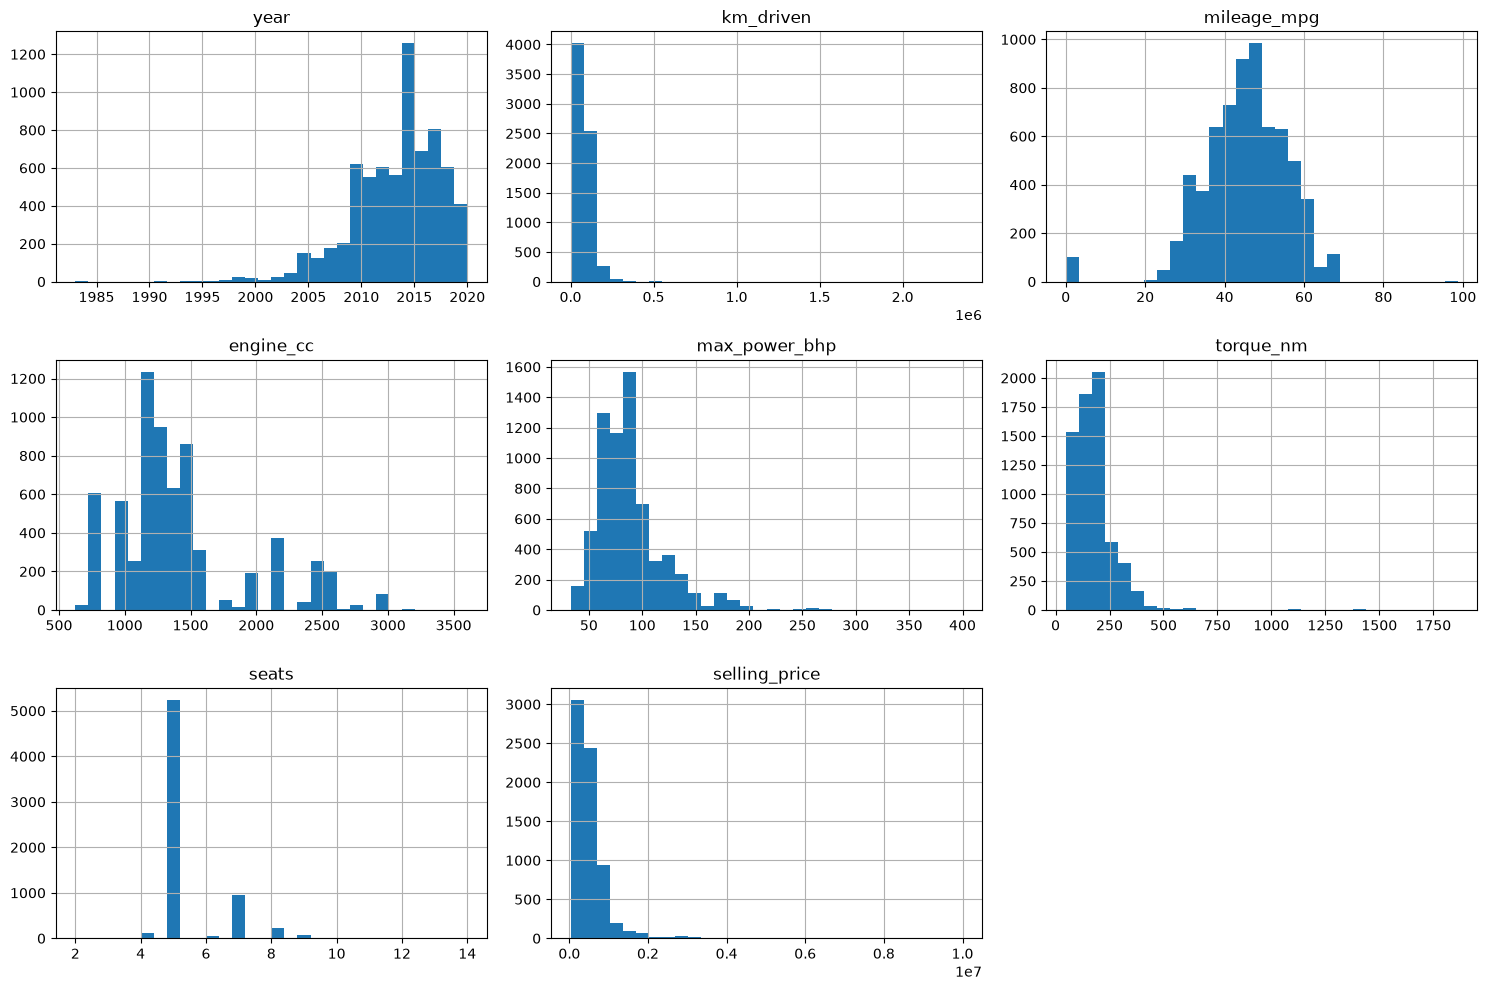

In [20]:
import matplotlib.pyplot as plt
  
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


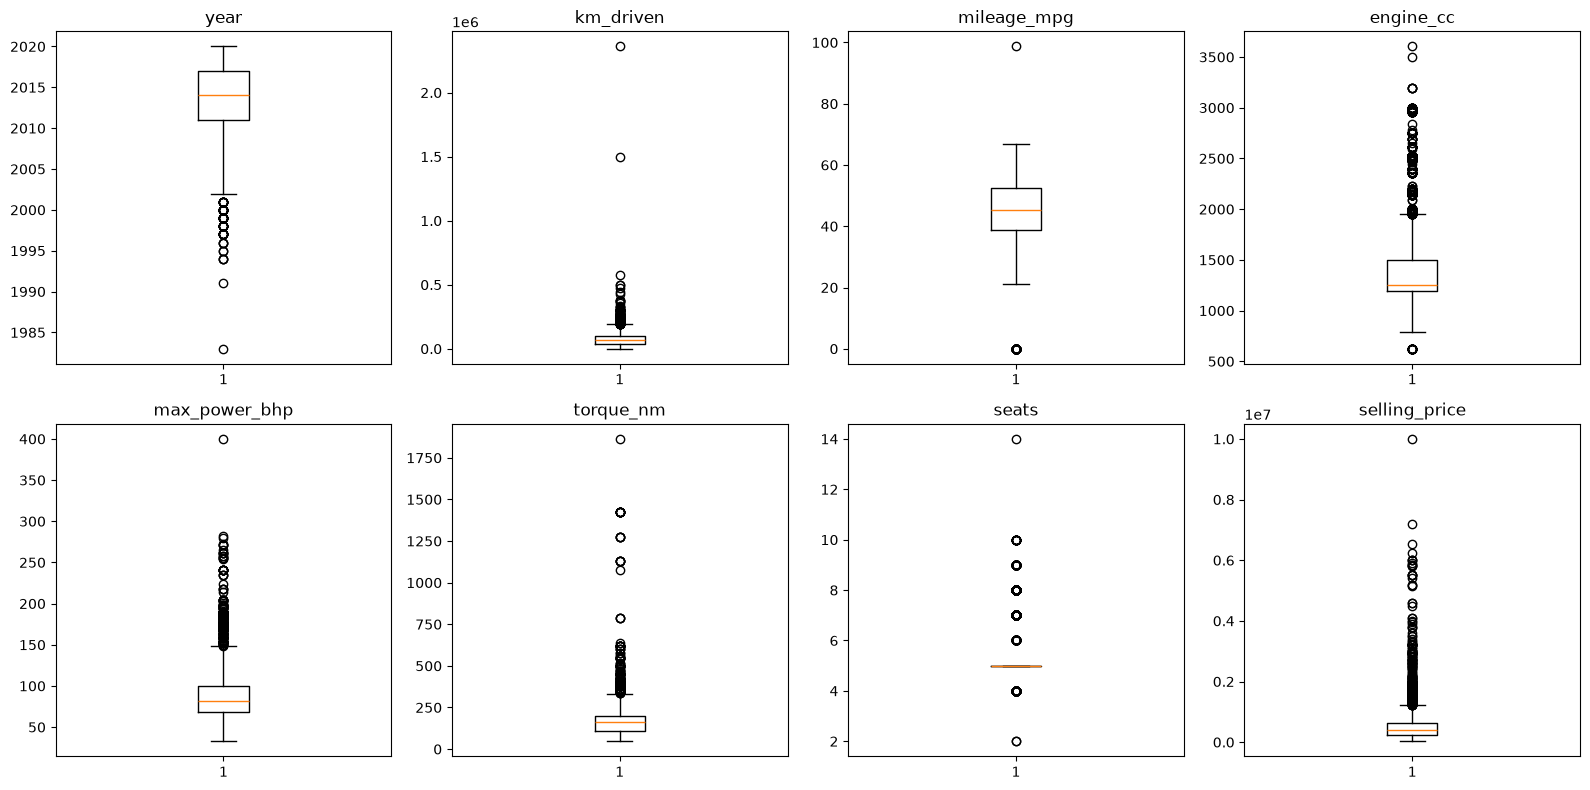

In [21]:
import matplotlib.pyplot as plt
  
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
      axes[i].boxplot(df[col].dropna())
      axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [22]:
for col in df.select_dtypes(include='number').columns:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
      print(f'{col}: {len(outliers)} outliers')


year: 77 outliers
km_driven: 166 outliers
mileage_mpg: 103 outliers
engine_cc: 1203 outliers
max_power_bhp: 305 outliers
torque_nm: 306 outliers
seats: 1459 outliers
selling_price: 327 outliers


In [23]:
mask = pd.Series(False, index=df.index)

for col in df.select_dtypes(include='number').columns:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      mask |= (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)

print(f'Total outlier rows: {mask.sum()}')
print(f'Rows remaining after removal: {(~mask).sum()}')


Total outlier rows: 1956
Rows remaining after removal: 4951


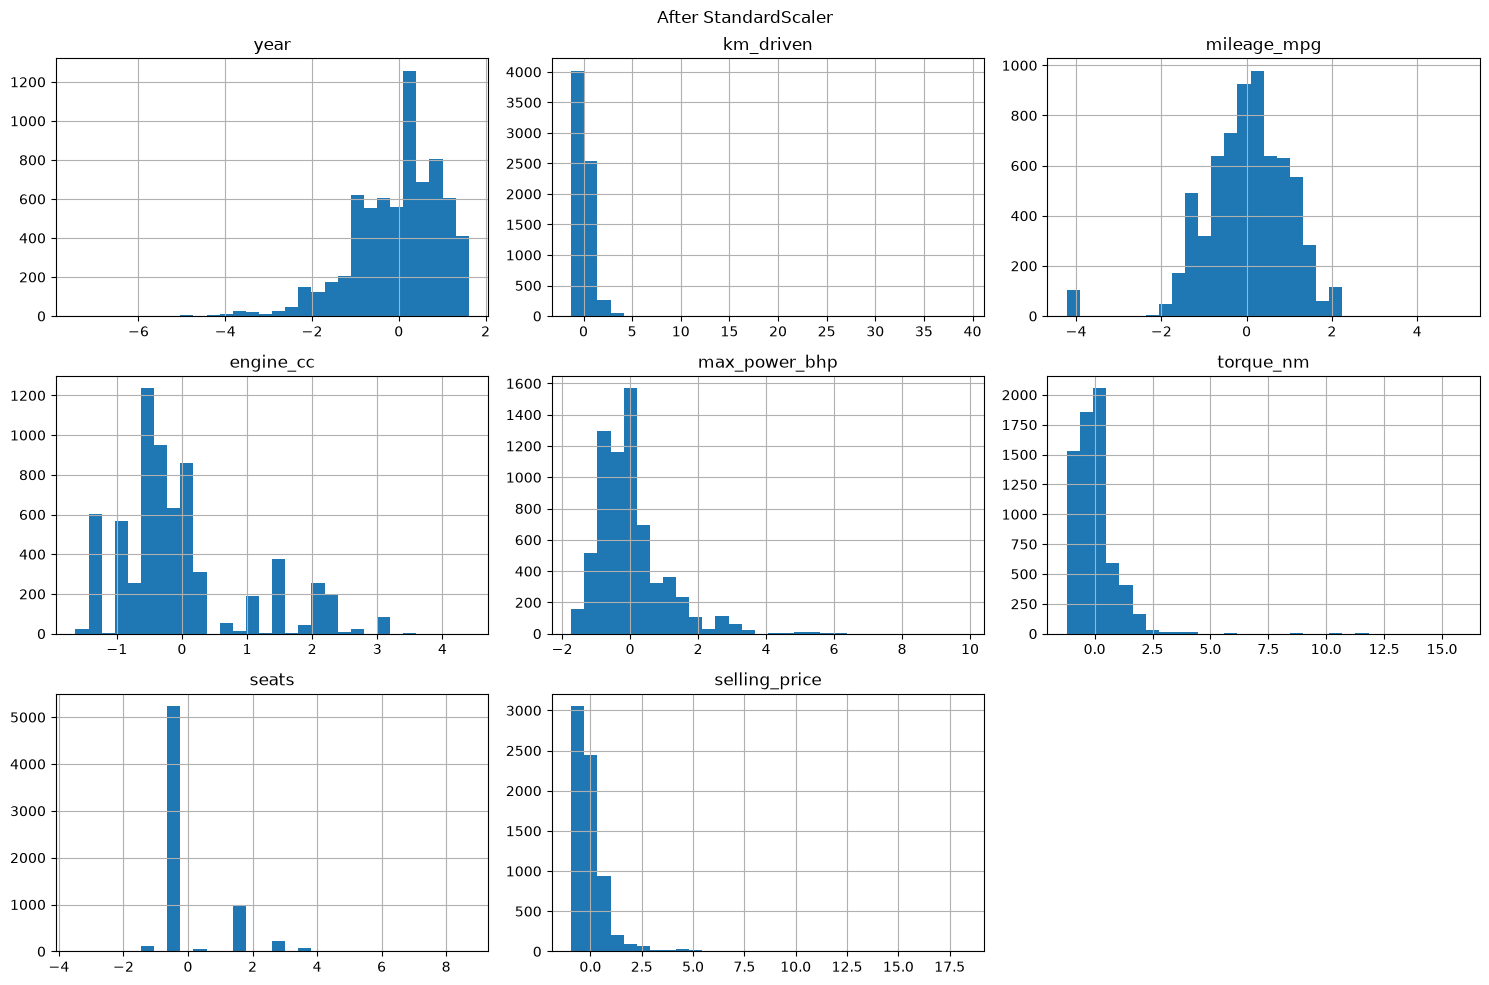

In [24]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.select_dtypes(include='number'))
scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include='number').columns)

scaled_df.hist(figsize=(15, 10), bins=30)
plt.suptitle('After StandardScaler')
plt.tight_layout()
plt.show()

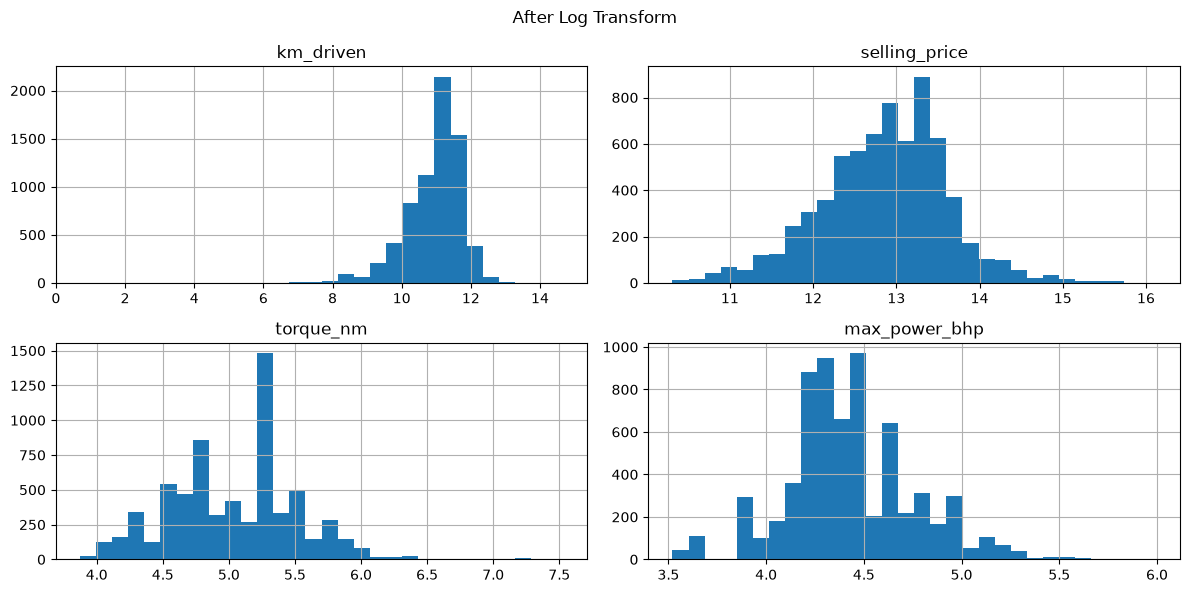

In [25]:
import numpy as np
import matplotlib.pyplot as plt

cols_to_log = ['km_driven', 'selling_price', 'torque_nm', 'max_power_bhp']
df[cols_to_log] = df[cols_to_log].apply(np.log1p)

df[cols_to_log].hist(figsize=(12, 6), bins=30)
plt.suptitle('After Log Transform')
plt.tight_layout()
plt.show()


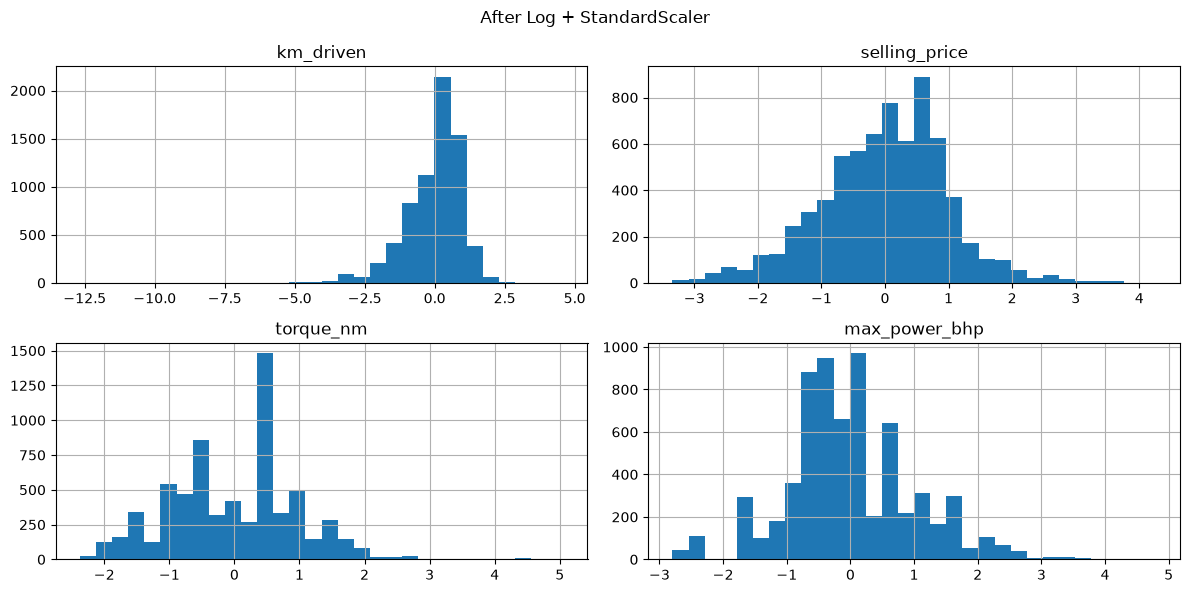

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df[cols_to_log])
scaled_df = pd.DataFrame(scaled, columns=cols_to_log)

scaled_df.hist(figsize=(12, 6), bins=30)
plt.suptitle('After Log + StandardScaler')
plt.suptitle('After Log + StandardScaler')
plt.tight_layout()
plt.show()

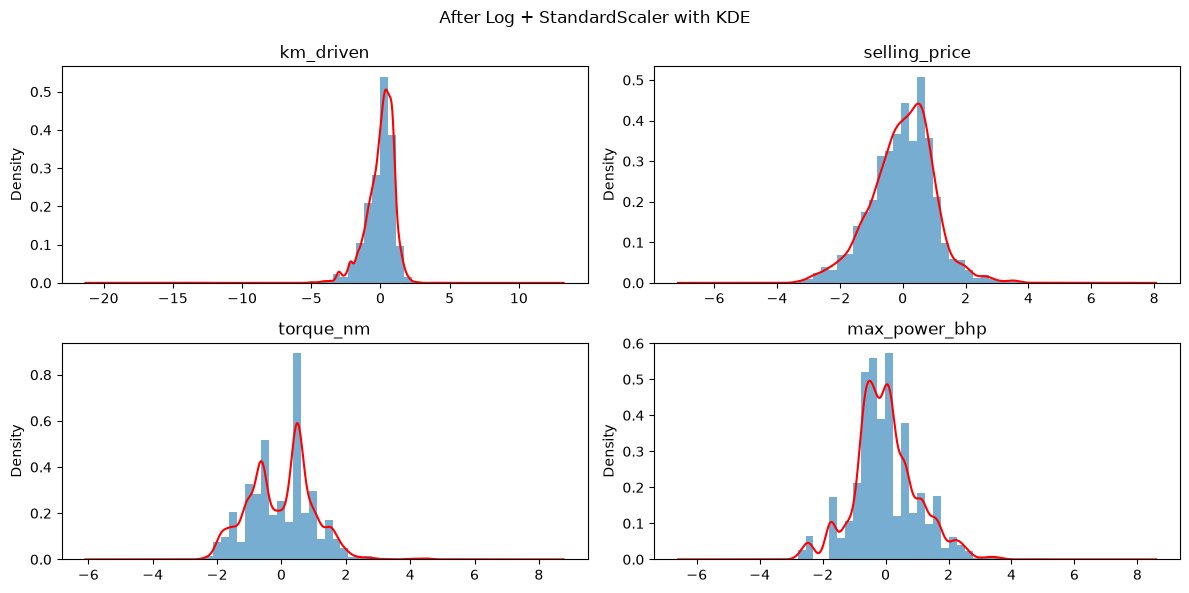

In [27]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df[cols_to_log])
scaled_df = pd.DataFrame(scaled, columns=cols_to_log)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(cols_to_log):
      axes[i].hist(scaled_df[col], bins=30, density=True, alpha=0.6)
      scaled_df[col].plot.kde(ax=axes[i], color='red')
      axes[i].set_title(col)

plt.suptitle('After Log + StandardScaler with KDE')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

mlp_model = Pipeline(steps=[
      ('pre', preprocessor),
      ('reg', MLPRegressor(random_state=42, max_iter=500))
  ])

param_grid = {
      'reg__hidden_layer_sizes': [(64, 32), (128, 64), (64, 64, 32)],
      'reg__activation': ['relu', 'tanh'],
      'reg__alpha': [0.001, 0.01],
      'reg__learning_rate_init': [0.001, 0.01]
  }

search = GridSearchCV(
      mlp_model, param_grid, cv=5,
      scoring='neg_root_mean_squared_error', n_jobs=-1
  )
search.fit(X_train, y_train)

print(search.best_params_)

y_train_pred = np.expm1(search.predict(X_train))
y_test_pred = np.expm1(search.predict(X_test))
print(f'Train RMSE: {root_mean_squared_error(np.expm1(y_train), y_train_pred):,.3f}')
print(f'Test RMSE: {root_mean_squared_error(np.expm1(y_test), y_test_pred):,.3f}')

c:\Users\sj941\OneDrive\Desktop\Data Science\backend_fastapi\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
C:\Users\sj941\AppData\Local\Temp\ipykernel_5528\4101925314.py:24: RuntimeWarning: overflow encountered in expm1
  y_train_pred = np.expm1(search.predict(X_train))
C:\Users\sj941\AppData\Local\Temp\ipykernel_5528\4101925314.py:25: RuntimeWarning: overflow encountered in expm1
  y_test_pred = np.expm1(search.predict(X_test))
c:\Users\sj941\OneDrive\Desktop\Data Science\backend_fastapi\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


{'reg__activation': 'relu', 'reg__alpha': 0.01, 'reg__hidden_layer_sizes': (64, 32), 'reg__learning_rate_init': 0.01}


ValueError: Input contains infinity or a value too large for dtype('float64').

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

# preprocess using existing pipeline preprocessor
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

  # convert to tensors and move to GPU
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)

  # define model
  class CarPriceNN(nn.Module):
      def __init__(self):
          super().__init__()
          self.net = nn.Sequential(
              nn.Linear(X_train_scaled.shape[1], 128),
              nn.ReLU(),
              nn.Linear(128, 64),
              nn.ReLU(),
              nn.Linear(64, 32),
              nn.ReLU(),
              nn.Linear(32, 1)
          )
      def forward(self, x):
          return self.net(x)

  model = CarPriceNN().to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  criterion = nn.MSELoss()

  # train
  loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

  for epoch in range(100):
      model.train()
      for X_batch, y_batch in loader:
          optimizer.zero_grad()
          loss = criterion(model(X_batch), y_batch)
          loss.backward()
          optimizer.step()
      if (epoch+1) % 10 == 0:
          print(f'Epoch {epoch+1}/100  Loss: {loss.item():.4f}')

  # evaluate
  model.eval()
  with torch.no_grad():
      y_train_pred = np.expm1(model(X_train_t).cpu().numpy().flatten())
      y_test_pred  = np.expm1(model(X_test_t).cpu().numpy().flatten())

  print(f'Train RMSE: {root_mean_squared_error(np.expm1(y_train), y_train_pred):,.3f}')
  print(f'Test RMSE:  {root_mean_squared_error(np.expm1(y_test),  y_test_pred):,.3f}')


In [29]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import root_mean_squared_error

import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

# Preprocess using the existing pipeline
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Convert to tensors and move to GPU/CPU
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)

# Define model
class CarPriceNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train_scaled.shape[1], 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = CarPriceNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

for epoch in range(100):
    model.train()
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}/100  Loss: {loss.item():.4f}')

# Evaluate
model.eval()
with torch.no_grad():
    y_train_pred = np.expm1(model(X_train_t).cpu().numpy().flatten())
    y_test_pred = np.expm1(model(X_test_t).cpu().numpy().flatten())

print(f'Train RMSE: {root_mean_squared_error(np.expm1(y_train), y_train_pred):,.3f}')
print(f'Test RMSE:  {root_mean_squared_error(np.expm1(y_test), y_test_pred):,.3f}')

Using: cpu
Epoch 10/100  Loss: 109526663168.0000
Epoch 20/100  Loss: 47955677184.0000
Epoch 30/100  Loss: 50160644096.0000
Epoch 40/100  Loss: 42974941184.0000
Epoch 50/100  Loss: 308207124480.0000
Epoch 60/100  Loss: 215013277696.0000
Epoch 70/100  Loss: 14496121856.0000
Epoch 80/100  Loss: 6736563200.0000
Epoch 90/100  Loss: 86820978688.0000
Epoch 100/100  Loss: 22212864000.0000


C:\Users\sj941\AppData\Local\Temp\ipykernel_5528\3126772784.py:59: RuntimeWarning: overflow encountered in expm1
  y_train_pred = np.expm1(model(X_train_t).cpu().numpy().flatten())
C:\Users\sj941\AppData\Local\Temp\ipykernel_5528\3126772784.py:60: RuntimeWarning: overflow encountered in expm1
  y_test_pred = np.expm1(model(X_test_t).cpu().numpy().flatten())
c:\Users\sj941\OneDrive\Desktop\Data Science\backend_fastapi\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: Input contains infinity or a value too large for dtype('float64').

In [30]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

  # preprocess using existing pipeline preprocessor
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

  # convert to tensors and move to GPU
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)

  # define model
class CarPriceNN(nn.Module):
      def __init__(self):
          super().__init__()
          self.net = nn.Sequential(
              nn.Linear(X_train_scaled.shape[1], 128),
              nn.ReLU(),
              nn.Dropout(0.2),
              nn.Linear(128, 64),
              nn.ReLU(),
              nn.Dropout(0.2),
              nn.Linear(64, 32),
              nn.ReLU(),
              nn.Linear(32, 1)
          )
      def forward(self, x):
          return self.net(x)

model = CarPriceNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

  # train
loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

for epoch in range(100):
      model.train()
      for X_batch, y_batch in loader:
          optimizer.zero_grad()
          loss = criterion(model(X_batch), y_batch)
          loss.backward()
          optimizer.step()
      if (epoch+1) % 10 == 0:
          print(f'Epoch {epoch+1}/100  Loss: {loss.item():.4f}')

  # evaluate
model.eval()
with torch.no_grad():
      y_train_pred_log = np.clip(model(X_train_t).cpu().numpy().flatten(), 0, 20)
      y_test_pred_log  = np.clip(model(X_test_t).cpu().numpy().flatten(), 0, 20)

y_train_pred = np.expm1(y_train_pred_log)
y_test_pred  = np.expm1(y_test_pred_log)

print(f'Train RMSE: {root_mean_squared_error(np.expm1(y_train), y_train_pred):,.3f}')
print(f'Test RMSE:  {root_mean_squared_error(np.expm1(y_test),  y_test_pred):,.3f}')

Using: cpu
Epoch 10/100  Loss: 12729932800.0000
Epoch 20/100  Loss: 19390351360.0000
Epoch 30/100  Loss: 13715374080.0000
Epoch 40/100  Loss: 13368549376.0000
Epoch 50/100  Loss: 24891863040.0000
Epoch 60/100  Loss: 39274110976.0000
Epoch 70/100  Loss: 20035104768.0000
Epoch 80/100  Loss: 13546031104.0000
Epoch 90/100  Loss: 31956084736.0000
Epoch 100/100  Loss: 25392183296.0000


c:\Users\sj941\OneDrive\Desktop\Data Science\backend_fastapi\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: Input contains infinity or a value too large for dtype('float64').

In [ ]:
import pandas as pd 
  import numpy as np
  import torch
  import torch.nn as nn
  from torch.utils.data import DataLoader, TensorDataset
  from typing import List
  from sklearn.model_selection import train_test_split
  from sklearn.pipeline import Pipeline
  from sklearn.compose import ColumnTransformer
  from sklearn.impute import SimpleImputer
  from sklearn.preprocessing import StandardScaler, OneHotEncoder
  from sklearn.metrics import root_mean_squared_error

  # ── 1. LOAD ───────────────────────────────────────────────
  df = pd.read_csv('car-details.csv')

  # ── 2. CLEAN ──────────────────────────────────────────────
  df = df.drop(columns=['name', 'model', 'edition'])
  df = df.drop_duplicates()

  # ── 3. IMPUTE (company-wise) ──────────────────────────────
  def impute_columns(columns: List[str]):
      list(map(
          lambda col: df.__setitem__(
              col,
              df.groupby('company')[col].transform(
                  lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else df[col].mode().iloc[0])
                  if df[col].dtype == 'object'
                  else x.fillna(x.median() if pd.notna(x.median()) else df[col].median())
              )
          ),
          columns
      ))

  impute_columns(['mileage_mpg', 'engine_cc', 'max_power_bhp', 'torque_nm', 'seats'])

  # ── 4. LOG TRANSFORM ──────────────────────────────────────
  log_cols = ['km_driven', 'selling_price', 'torque_nm', 'max_power_bhp']
  df[log_cols] = df[log_cols].apply(np.log1p)

  # ── 5. SPLIT ──────────────────────────────────────────────
  X = df.drop(columns='selling_price')
  y = df['selling_price']  # already log-transformed

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # ── 6. PREPROCESS ─────────────────────────────────────────
  num_cols = X_train.select_dtypes(include='number').columns.tolist()
  cat_cols = [col for col in X_train.columns if col not in num_cols]

  preprocessor = ColumnTransformer(transformers=[
      ('num', Pipeline([
          ('imputer', SimpleImputer(strategy='median')),
          ('scaler', StandardScaler())
      ]), num_cols),
      ('cat', Pipeline([
          ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
          ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
      ]), cat_cols)
  ])

  X_train_scaled = preprocessor.fit_transform(X_train)
  X_test_scaled  = preprocessor.transform(X_test)

  # ── 7. PYTORCH SETUP ──────────────────────────────────────
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  print(f'Using: {device}')

  X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
  y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
  X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)

  # ── 8. MODEL ──────────────────────────────────────────────
  class CarPriceNN(nn.Module):
      def __init__(self, input_dim):
          super().__init__()
          self.net = nn.Sequential(
              nn.Linear(input_dim, 128),
              nn.BatchNorm1d(128),
              nn.ReLU(),
              nn.Dropout(0.2),
              nn.Linear(128, 64),
              nn.BatchNorm1d(64),
              nn.ReLU(),
              nn.Dropout(0.2),
              nn.Linear(64, 32),
              nn.ReLU(),
              nn.Linear(32, 1)
          )
      def forward(self, x):
          return self.net(x)

  model     = CarPriceNN(X_train_scaled.shape[1]).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  criterion = nn.MSELoss()
  loader    = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

  # ── 9. TRAIN ──────────────────────────────────────────────
  for epoch in range(100):
      model.train()
      for X_batch, y_batch in loader:
          optimizer.zero_grad()
          loss = criterion(model(X_batch), y_batch)
          loss.backward()
          optimizer.step()
      if (epoch+1) % 10 == 0:
          print(f'Epoch {epoch+1}/100  Loss: {loss.item():.4f}')

  # ── 10. EVALUATE ──────────────────────────────────────────
  model.eval()
  with torch.no_grad():
      y_train_pred = model(X_train_t).cpu().numpy().flatten()
      y_test_pred  = model(X_test_t).cpu().numpy().flatten()

  # convert log predictions back to actual prices
  y_train_pred = np.expm1(y_train_pred)
  y_test_pred  = np.expm1(y_test_pred)
  y_train_actual = np.expm1(y_train.values)
  y_test_actual  = np.expm1(y_test.values)

  print(f'Train RMSE: {root_mean_squared_error(y_train_actual, y_train_pred):,.3f}')
  print(f'Test RMSE:  {root_mean_squared_error(y_test_actual,  y_test_pred):,.3f}')

In [31]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from typing import List
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import root_mean_squared_error

  # ── 1. LOAD ───────────────────────────────────────────────
df = pd.read_csv('car-details.csv')

  # ── 2. CLEAN ──────────────────────────────────────────────
df = df.drop(columns=['name', 'model', 'edition'])
df = df.drop_duplicates()

  # ── 3. IMPUTE (company-wise) ──────────────────────────────
def impute_columns(columns: List[str]):
      list(map(
          lambda col: df.__setitem__(
              col,
              df.groupby('company')[col].transform(
                  lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else df[col].mode().iloc[0])
                  if df[col].dtype == 'object'
                  else x.fillna(x.median() if pd.notna(x.median()) else df[col].median())
              )
          ),
          columns
      ))

impute_columns(['mileage_mpg', 'engine_cc', 'max_power_bhp', 'torque_nm', 'seats'])

  # ── 4. SPLIT ──────────────────────────────────────────────
X = df.drop(columns='selling_price')
y = np.log1p(df['selling_price'])  # log transform target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # ── 5. PIPELINE (log transform inside for features) ───────
num_cols_to_log = ['km_driven', 'torque_nm', 'max_power_bhp']
num_cols_no_log = ['year', 'mileage_mpg', 'engine_cc', 'seats']
cat_cols        = ['company', 'owner', 'fuel', 'seller_type', 'transmission']

log_num_pipe = Pipeline([
      ('log',     FunctionTransformer(np.log1p)),
      ('imputer', SimpleImputer(strategy='median')),
      ('scaler',  StandardScaler())
  ])

num_pipe = Pipeline([
      ('imputer', SimpleImputer(strategy='median')),
      ('scaler',  StandardScaler())
  ])

cat_pipe = Pipeline([
      ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
      ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
  ])

preprocessor = ColumnTransformer(transformers=[
      ('log_num', log_num_pipe, num_cols_to_log),
      ('num',     num_pipe,     num_cols_no_log),
      ('cat',     cat_pipe,     cat_cols)
  ])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)

  # ── 6. PYTORCH SETUP ──────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)

  # ── 7. MODEL ──────────────────────────────────────────────
class CarPriceNN(nn.Module):
      def __init__(self, input_dim):
          super().__init__()
          self.net = nn.Sequential(
              nn.Linear(input_dim, 128),
              nn.BatchNorm1d(128),
              nn.ReLU(),
              nn.Dropout(0.2),
              nn.Linear(128, 64),
              nn.BatchNorm1d(64),
              nn.ReLU(),
              nn.Dropout(0.2),
              nn.Linear(64, 32),
              nn.ReLU(),
              nn.Linear(32, 1)
          )
      def forward(self, x):
          return self.net(x)

model     = CarPriceNN(X_train_scaled.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
loader    = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

  # ── 8. TRAIN ──────────────────────────────────────────────
for epoch in range(100):
      model.train()
      for X_batch, y_batch in loader:
          optimizer.zero_grad()
          loss = criterion(model(X_batch), y_batch)
          loss.backward()
          optimizer.step()
      if (epoch+1) % 10 == 0:
          print(f'Epoch {epoch+1}/100  Loss: {loss.item():.4f}')

  # ── 9. EVALUATE ───────────────────────────────────────────
model.eval()
with torch.no_grad():
      y_train_pred = model(X_train_t).cpu().numpy().flatten()
      y_test_pred  = model(X_test_t).cpu().numpy().flatten()

print(f'Train RMSE: {root_mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred)):,.3f}')
print(f'Test RMSE:  {root_mean_squared_error(np.expm1(y_test),  np.expm1(y_test_pred)):,.3f}')


C:\Users\sj941\AppData\Local\Temp\ipykernel_5528\1432332015.py:24: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  lambda col: df.__setitem__(
C:\Users\sj941\AppData\Local\Temp\ipykernel_5528\1432332015.py:24: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due 

Using: cpu
Epoch 10/100  Loss: 1.1174
Epoch 20/100  Loss: 1.6317
Epoch 30/100  Loss: 1.2877
Epoch 40/100  Loss: 0.5352
Epoch 50/100  Loss: 0.1685
Epoch 60/100  Loss: 0.1030
Epoch 70/100  Loss: 0.1223
Epoch 80/100  Loss: 0.0659
Epoch 90/100  Loss: 0.0742
Epoch 100/100  Loss: 0.1528
Train RMSE: 246,230.211
Test RMSE:  225,956.670


In [32]:
from sklearn.linear_model import LinearRegression
  
lr_model = Pipeline(steps=[
      ('pre', preprocessor),
      ('reg', LinearRegression())
])

lr_model.fit(X_train, y_train)

y_train_pred = lr_model.predict(X_train)
y_test_pred  = lr_model.predict(X_test)

print(f'Train RMSE: {root_mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred)):,.3f}')
print(f'Test RMSE:  {root_mean_squared_error(np.expm1(y_test),  np.expm1(y_test_pred)):,.3f}')

Train RMSE: 179,446.069
Test RMSE:  163,858.893


In [33]:
import joblib
  
joblib.dump(search.best_estimator_, 'car_price_model.pkl')

['car_price_model.pkl']

In [34]:
model = joblib.load('car_price_model.pkl')
model.predict(X_test)

array([2776320.80686913,  329855.9514365 ,  142459.93515787, ...,
        171910.59757558,  635689.45069304,  240351.0828466 ],
      shape=(1382,))